Refer to Tensorflow Object Detection API here: https://tensorflow-object-detection-api-tutorial.readthedocs.io/en/latest/index.html

In [ ]:
## Project Directory structure
'''
<Project name>
--object_detection (From tensorflow/models/research)
--slim (From tensorflow/models/research)
--images (From ArcGIS export)
--labels (From ArcGIS export)
--data (TF Records and label mapping will be saved here)
--test_images (images to be tested on)
--models
    --train (the training files will be saved here)
    --fine_tuned_model (Frozen inference graph and related files to be saved here)
    --model.ckpt.xxxx (3 files - from a pre-trained model)
--pipeline_config.config (The pipeline config file)
--train.py
--export_inference_graph.py
'''

In [19]:
# import
import hashlib
import io
import logging
import os
import glob
import random
from pathlib import Path
import numpy as np

from lxml import etree
import PIL.Image
import matplotlib.pyplot as plt

import tensorflow as tf

from object_detection.utils import dataset_util
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as vis_util

In [21]:
%matplotlib inline

### Create TF Records

In [6]:
def dict_to_tf_example(data,
                       image_path,
                       label_map_dict,
                       ignore_difficult_instances=False,
                       class_mapping=None):
    """Convert XML derived dict to tf.Example proto.
    Notice that this function normalizes the bounding box coordinates provided
    by the raw data.
    Args:
    data: dict holding PASCAL XML fields for a single image (obtained by
      running dataset_util.recursive_parse_xml_to_dict)
    image_path: Path to image described by the PASCAL XML file
    label_map_dict: A map from string label names to integers ids.
    ignore_difficult_instances: Whether to skip difficult instances in the
      dataset  (default: False).
    Returns:
    example: The converted tf.Example.
    Raises:
    ValueError: if the image pointed to by data['filename'] is not a valid JPEG
    """
    with tf.gfile.GFile(image_path, 'rb') as fid:
        encoded_jpg = fid.read()
    encoded_jpg_io = io.BytesIO(encoded_jpg)
    image = PIL.Image.open(encoded_jpg_io)
    if image.format != 'JPEG':
        raise ValueError('Image format not JPEG')
    key = hashlib.sha256(encoded_jpg).hexdigest()

    width = int(data['size']['width'])
    height = int(data['size']['height'])

    xmin = []
    ymin = []
    xmax = []
    ymax = []
    classes = []
    classes_text = []
    truncated = []
    poses = []
    difficult_obj = []
    for obj in data['object']:

        xmin.append(float(obj['bndbox']['xmin']) / width)
        ymin.append(float(obj['bndbox']['ymin']) / height)
        xmax.append(float(obj['bndbox']['xmax']) / width)
        ymax.append(float(obj['bndbox']['ymax']) / height)
        classes_text.append(class_mapping[int(obj['name'])].encode('utf8'))
        classes.append(label_map_dict[class_mapping[int(obj['name'])]])

    example = tf.train.Example(features=tf.train.Features(feature={
      'image/height': dataset_util.int64_feature(height),
      'image/width': dataset_util.int64_feature(width),
      'image/filename': dataset_util.bytes_feature(
          data['filename'].encode('utf8')),
      'image/source_id': dataset_util.bytes_feature(
          data['filename'].encode('utf8')),
      'image/key/sha256': dataset_util.bytes_feature(key.encode('utf8')),
      'image/encoded': dataset_util.bytes_feature(encoded_jpg),
      'image/format': dataset_util.bytes_feature('jpeg'.encode('utf8')),
      'image/object/bbox/xmin': dataset_util.float_list_feature(xmin),
      'image/object/bbox/xmax': dataset_util.float_list_feature(xmax),
      'image/object/bbox/ymin': dataset_util.float_list_feature(ymin),
      'image/object/bbox/ymax': dataset_util.float_list_feature(ymax),
      'image/object/class/text': dataset_util.bytes_list_feature(classes_text),
      'image/object/class/label': dataset_util.int64_list_feature(classes),
      'image/object/difficult': dataset_util.int64_list_feature(difficult_obj),
      'image/object/truncated': dataset_util.int64_list_feature(truncated),
      'image/object/view': dataset_util.bytes_list_feature(poses),
    }))
    return example

In [61]:
def prepare_data(path, class_mapping, chip_size=224, val_split_pct=0.1, batch_size=64, transforms=None, seed=42):
    
    path = Path(path)  #/ 'data'
    
    label_map_path = str(path / 'data' / 'label_map.pbtxt')
    
    with open(path / label_map_path, 'w') as f:
        for idx,name in enumerate(list(class_mapping.values())):
            print('item {\n  id: ' + f'{idx + 1}' + '\n  name: '+ f"'{name}'"+'\n}', file = f)
    
    label_map_dict = label_map_util.get_label_map_dict(label_map_path)
    
    data_dir_jpg_query = os.path.join(path, 'images', '*.jpg')
    data_dir_label_query = os.path.join(path, 'labels')

    files = glob.glob(data_dir_jpg_query)
    val_split_num = int(val_split_pct * len(files))
    random.shuffle(files)
    train_files = files[:-val_split_num]
    val_files = files[-val_split_num:]
    
    
    ############## data FOLDER ############
    path = path / 'data'
    
    output_paths = [path /  'train.record', path / 'val.record'] 
    
    dataset_files = [train_files, val_files]
    
    for output_path, dataset_file in zip(output_paths, dataset_files):
        output_path.parent.mkdir(exist_ok=True)
        writer = tf.python_io.TFRecordWriter(str(output_path))
    
        for idx, image_path in enumerate(dataset_file):
            if idx % 20 == 0:
#                 pass
                print(f'On image {idx} {image_path}', end='\r')#, idx, image_path)

            annotation_path = os.path.join(data_dir_label_query, os.path.basename(image_path).split('.')[0] + '.xml')

            with tf.gfile.GFile(annotation_path, 'r') as fid:
                xml_str = fid.read()

            xml = etree.fromstring(xml_str)
            data = dataset_util.recursive_parse_xml_to_dict(xml)['annotation']
#             print (data)
#             print(label_map_dict)
            tf_example = dict_to_tf_example(data, image_path, label_map_dict, True, class_mapping)
        #                                     FLAGS.ignore_difficult_instances)

            writer.write(tf_example.SerializeToString())

        writer.close()
        
    return {'train':output_paths[0],
            'valid':output_paths[1]}

In [62]:
# Provide the path to your project directory
path = r'C:\palmtrees'

In [63]:
# Create a class mapping where the keys are label names from arcgis export and the value is the actual label
class_mapping = {1: 'palm'}

In [64]:
prepare_data(path, class_mapping)

{'train': WindowsPath('C:/palmtrees/tf/train.record'),
 'valid': WindowsPath('C:/palmtrees/tf/val.record')}

### Parts to be scripted

Download the desired pre-trained model from the TF Model Zoo: 
https://github.com/tensorflow/models/blob/master/research/object_detection/g3doc/detection_model_zoo.md#coco-trained-models-coco-models

Modify the pipeline-config file

Modify the train file to include the path for 'slim' in the environment path

Train: python train.py --logtostderr --train_dir=models/train --pipeline_config_path=pipeline_config.config

Exporting a trained inference graph: python export_inference_graph.py --input_type image_tensor --pipeline_config_path pipeline_config.config --trained_checkpoint_prefix training/model.ckpt-<xxxx> --output_directory models/fine_tuned_model
    
Evaluation

### Load model

In [8]:
PATH_TO_FROZEN_GRAPH = 'models/fine_tuned_model/frozen_inference_graph.pb'

detection_graph = tf.Graph()
with detection_graph.as_default():
  od_graph_def = tf.GraphDef()
  with tf.gfile.GFile(PATH_TO_FROZEN_GRAPH, 'rb') as fid:
    serialized_graph = fid.read()
    od_graph_def.ParseFromString(serialized_graph)
    tf.import_graph_def(od_graph_def, name='')

In [9]:
PATH_TO_LABELS = os.path.join('data', 'label_map.pbtxt')

category_index = label_map_util.create_category_index_from_labelmap(PATH_TO_LABELS, use_display_name=True)

In [10]:
category_index

{1: {'id': 1, 'name': 'palm'}}

### Detection

In [23]:
PATH_TO_TEST_IMAGES_DIR = 'test_images'
# TEST_IMAGES_PATHS can be defined according to the given data
TEST_IMAGE_PATHS = [ os.path.join(PATH_TO_TEST_IMAGES_DIR, '00000000{}.jpg'.format(i)) for i in range(1, 5) ]

# Size, in inches, of the output images.
IMAGE_SIZE = (8, 8)

In [11]:
# Helper function to load image and convert it into numpy array for detection
def load_image_into_numpy_array(image):
  (im_width, im_height) = image.size
  return np.array(image.getdata()).reshape(
      (im_height, im_width, 3)).astype(np.uint8)

In [13]:
def run_inference_for_single_image(image, graph):
  with graph.as_default():
    with tf.Session() as sess:
      # Get handles to input and output tensors
      ops = tf.get_default_graph().get_operations()
      all_tensor_names = {output.name for op in ops for output in op.outputs}
      tensor_dict = {}
      for key in [
          'num_detections', 'detection_boxes', 'detection_scores',
          'detection_classes', 'detection_masks'
      ]:
        tensor_name = key + ':0'
        if tensor_name in all_tensor_names:
          tensor_dict[key] = tf.get_default_graph().get_tensor_by_name(
              tensor_name)
      if 'detection_masks' in tensor_dict:
        # The following processing is only for single image
        detection_boxes = tf.squeeze(tensor_dict['detection_boxes'], [0])
        detection_masks = tf.squeeze(tensor_dict['detection_masks'], [0])
        # Reframe is required to translate mask from box coordinates to image coordinates and fit the image size.
        real_num_detection = tf.cast(tensor_dict['num_detections'][0], tf.int32)
        detection_boxes = tf.slice(detection_boxes, [0, 0], [real_num_detection, -1])
        detection_masks = tf.slice(detection_masks, [0, 0, 0], [real_num_detection, -1, -1])
        detection_masks_reframed = utils_ops.reframe_box_masks_to_image_masks(
            detection_masks, detection_boxes, image.shape[1], image.shape[2])
        detection_masks_reframed = tf.cast(
            tf.greater(detection_masks_reframed, 0.5), tf.uint8)
        # Follow the convention by adding back the batch dimension
        tensor_dict['detection_masks'] = tf.expand_dims(
            detection_masks_reframed, 0)
      image_tensor = tf.get_default_graph().get_tensor_by_name('image_tensor:0')

      # Run inference
      output_dict = sess.run(tensor_dict,
                             feed_dict={image_tensor: image})

      # all outputs are float32 numpy arrays, so convert types as appropriate
      output_dict['num_detections'] = int(output_dict['num_detections'][0])
      output_dict['detection_classes'] = output_dict[
          'detection_classes'][0].astype(np.int64)
      output_dict['detection_boxes'] = output_dict['detection_boxes'][0]
      output_dict['detection_scores'] = output_dict['detection_scores'][0]
      if 'detection_masks' in output_dict:
        output_dict['detection_masks'] = output_dict['detection_masks'][0]
  return output_dict

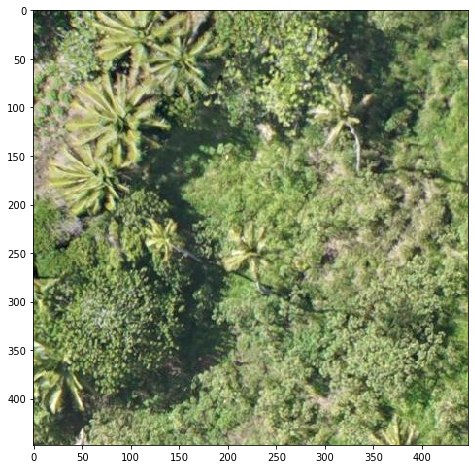

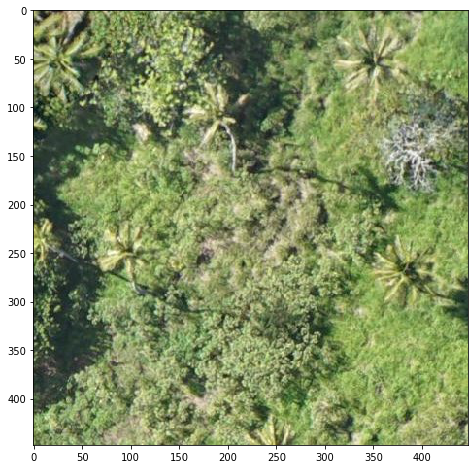

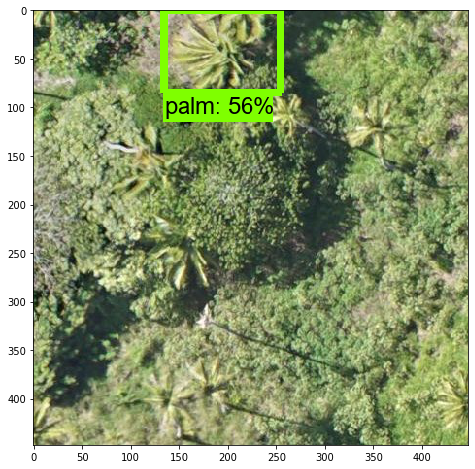

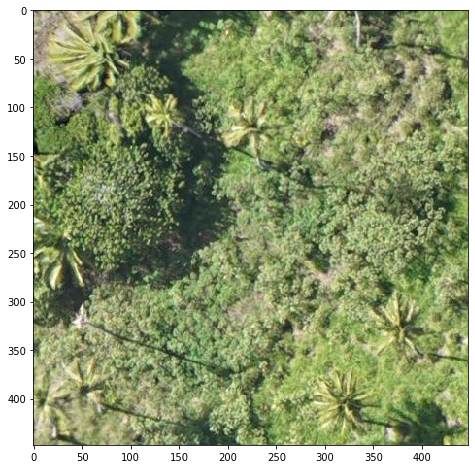

In [24]:
for image_path in TEST_IMAGE_PATHS:
  image = PIL.Image.open(image_path)
  # the array based representation of the image will be used later in order to prepare the
  # result image with boxes and labels on it.
  image_np = load_image_into_numpy_array(image)
  # Expand dimensions since the model expects images to have shape: [1, None, None, 3]
  image_np_expanded = np.expand_dims(image_np, axis=0)
  # Actual detection.
  output_dict = run_inference_for_single_image(image_np_expanded, detection_graph)
  # Visualization of the results of a detection.
  vis_util.visualize_boxes_and_labels_on_image_array(
      image_np,
      output_dict['detection_boxes'],
      output_dict['detection_classes'],
      output_dict['detection_scores'],
      category_index,
      instance_masks=output_dict.get('detection_masks'),
      use_normalized_coordinates=True,
      line_thickness=8)
  plt.figure(figsize=IMAGE_SIZE)
  plt.imshow(image_np)